In [1]:
%cd ../

/home/syed/VS code/globalretail-360


## Hypothesis 1: The Discount Trap

### Business Question
Do high discounts (>20%) increase the likelihood of product returns compared to low discounts (<10%)?

This analysis evaluates whether aggressive discounting attracts lower-quality transactions that result in higher return rates.

---

## Why This Matters

Discounting is commonly used to drive sales volume.  
However, if high discounts significantly increase return rates, the company may be sacrificing long-term profitability for short-term revenue.

Understanding this relationship informs:

- Pricing strategy  
- Promotion policy  
- Margin protection  
- Customer targeting decisions  

---

## Statistical Framing

We are testing whether **return rate is independent of discount level**.

### Independent Variable (IV)
Discount Category:
- Low Discount (<10%)
- High Discount (>20%)

### Dependent Variable (DV)
Return Flag:
- Returned (1)
- Not Returned (0)

This is a test of **difference in proportions**.

---

## Formal Hypotheses

Let:

- \( p_H \) = Return rate for High Discount orders (>20%)
- \( p_L \) = Return rate for Low Discount orders (<10%)

### Null Hypothesis (H₀)

The return rate is independent of discount level.

\[
H_0: p_H = p_L
\]

There is no statistically significant difference in return rates between high and low discount orders.

---

### Alternative Hypothesis (H₁)

High-discount orders have a higher return rate than low-discount orders.

\[
H_1: p_H > p_L
\]

This is a **one-tailed hypothesis**, because the business concern is specifically whether aggressive discounting increases returns.

In [2]:
import pandas as pd
from sqlalchemy import create_engine
from src.utils.config import ENV, POSTGRES_URI

engine = create_engine(POSTGRES_URI)

query = """
SELECT
    discount,
    return_flag
FROM fact_sales
WHERE discount IS NOT NULL;
"""

df = pd.read_sql(query, engine)

df.head()

,discount,return_flag
0,0.45,0
1,0.20,0
2,0.40,0
3,0.00,0
4,0.00,0


In [3]:
df.shape

(51593, 2)

In [4]:
low_discount = df[df["discount"] < 0.10].copy()
high_discount = df[df["discount"] > 0.20].copy()

low_discount["discount_group"] = "Low (<10%)"
high_discount["discount_group"] = "High (>20%)"

df_filtered = pd.concat([low_discount, high_discount])

df_filtered.head()

,discount,return_flag,discount_group
3,0.0,0,Low (<10%)
4,0.0,0,Low (<10%)
5,0.0,0,Low (<10%)
7,0.0,0,Low (<10%)
10,0.0,0,Low (<10%)


In [5]:
df_filtered["discount_group"].value_counts()

discount_group
Low (<10%)     29807
High (>20%)    11398
Name: count, dtype: int64

---

## Data Filtering & Group Definition

To create a clear comparison between discount extremes, we excluded orders with discounts between 10% and 20%.

### Rationale

The mid-range (10%–20%) represents moderate discounting and may blur the contrast between aggressive and minimal pricing strategies.

By focusing on:

- **Low Discount (<10%)**
- **High Discount (>20%)**

we create a sharper comparison, improving interpretability and avoiding dilution of the statistical signal.

### Final Sample Sizes

- Low Discount: 29,807 orders  
- High Discount: 11,398 orders  

Both groups have sufficiently large sample sizes for reliable inference.

In [6]:
return_rates = (
    df_filtered
    .groupby("discount_group")["return_flag"]
    .mean()
)

return_counts = (
    df_filtered
    .groupby("discount_group")["return_flag"]
    .agg(["sum", "count"])
)

return_rates, return_counts

(discount_group
 High (>20%)    0.133444
 Low (<10%)     0.112826
 Name: return_flag, dtype: float64,
                  sum  count
 discount_group             
 High (>20%)     1521  11398
 Low (<10%)      3363  29807)

## Descriptive Results (Before Statistical Testing)

### Return Rates

- **High Discount (>20%)**: 13.34%
- **Low Discount (<10%)**: 11.28%

### Absolute Difference

High-discount orders exhibit a **2.06 percentage point higher return rate** compared to low-discount orders.

### Preliminary Interpretation

At a descriptive level, aggressive discounting appears associated with a higher return rate.

However, descriptive differences alone do not indicate statistical significance.  
We must formally test whether this difference is unlikely to have occurred by random variation.

In [7]:
contingency_table = pd.crosstab(
    df_filtered["discount_group"],
    df_filtered["return_flag"]
)

contingency_table

return_flag,0,1
discount_group,,
High (>20%),9877,1521
Low (<10%),26444,3363


In [8]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

chi2, p_value, dof

(np.float64(33.35216913592821), np.float64(7.68920085104003e-09), 1)

In [9]:
expected

array([[10047.00298507,  1350.99701493],
       [26273.99701493,  3533.00298507]])

In [10]:
import numpy as np

n = contingency_table.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

cramers_v

np.float64(0.028450315248027172)

---

## Chi-Square Test Results

- **Chi-square statistic:** 33.35  
- **Degrees of freedom:** 1  
- **p-value:** < 0.001  
- **Cramér’s V:** 0.028  

### Statistical Decision

Because the p-value is far below 0.05, we reject the null hypothesis.

There is a statistically significant association between discount level and return rate.

---

## Effect Size Interpretation

Although statistically significant, the effect size (Cramér’s V = 0.028) is extremely small.

This indicates that:

- Discount level explains only a very small portion of variation in return behavior.
- The relationship, while real, is weak in magnitude.

---

## Business Interpretation

High-discount orders (>20%) show a 2.06 percentage point higher return rate than low-discount orders (<10%).

However, the practical impact of this difference is limited.

This suggests that:

- Aggressive discounting slightly increases return risk,
- But discounting alone is unlikely to be a major driver of returns.
- Other operational or customer-related factors may play a larger role.

---

## Key Insight

Large datasets can produce statistically significant results even when practical impact is minimal.

For decision-making, both **statistical significance** and **effect size** must be considered.

In [11]:
# Return rates
p_high = return_rates["High (>20%)"]
p_low = return_rates["Low (<10%)"]

# Sample sizes
n_high = return_counts.loc["High (>20%)", "count"]
n_low = return_counts.loc["Low (<10%)", "count"]

# Difference in proportions
diff = p_high - p_low

# Standard error
se = np.sqrt( (p_high*(1-p_high)/n_high) + (p_low*(1-p_low)/n_low) )

# 95% CI
from scipy.stats import norm
z = norm.ppf(0.975)  # 1.96
ci_lower = diff - z*se
ci_upper = diff + z*se

diff, ci_lower, ci_upper

(np.float64(0.02061861766332229),
 np.float64(0.013416310561491916),
 np.float64(0.027820924765152667))

---

## Confidence Interval for Difference in Return Rates

- Difference in return rates (High − Low): **2.06 percentage points**  
- 95% Confidence Interval: **1.34% – 2.78%**

### Interpretation

We are 95% confident that high-discount orders (>20%) have a return rate **between 1.34 and 2.78 percentage points higher** than low-discount orders (<10%).

### Business Insight

- The increase in return rate is **statistically significant**, but **practically small**.
- Aggressive discounting slightly increases returns, but the effect is minor in magnitude.
- Decision-makers should consider other operational factors when managing returns.
- Discount strategy may not be the main driver of returns, though small adjustments could optimize profitability.

---

### Key Takeaways

- Statistical significance ≠ practical significance  
- Confidence intervals communicate uncertainty in a business-friendly way  
- Effect sizes (Cramér’s V) contextualize the magnitude of the effect  

This completes a **full, professional analysis** of Hypothesis 1.

## Hypothesis 2: Shipping Leakage

### Business Question
Do “Critical” priority orders shipped via First Class in the Consumer segment frequently result in negative net profit margins?

This analysis evaluates whether high-cost shipping on high-priority orders is causing significant profitability loss for the company.

---

## Why This Matters

- High shipping costs can erode margins, especially on “Critical” priority orders.
- Identifying these inefficiencies helps:
  - Reduce losses
  - Improve unit economics
  - Optimize fulfillment and shipping strategy
- Specifically, we are testing whether ≥40% of such orders yield negative net profit margins.

---

## Statistical Framing

- **Independent Variables (IVs):**
  - Order Priority = “Critical”
  - Shipping Mode = “First Class”
  - Customer Segment = “Consumer”

- **Dependent Variable (DV):**
  - Net Profit Margin per order
    - Negative Margin (1) vs Non-Negative Margin (0)

We are testing **proportion of orders with negative margins**.

In [12]:
engine = create_engine(POSTGRES_URI)

query = """
SELECT
    f.order_id,
    c.segment,
    o."Order Priority" as order_priority,
    o."Ship Mode" as ship_mode,
    f.profit,
    f.sales
FROM fact_sales f
JOIN dim_customers c
    ON f.customer_key = c.customer_key
JOIN orders o
    ON f.order_id = o."Order ID"
WHERE c.segment IS NOT NULL
  AND o."Order Priority" IS NOT NULL
  AND o."Ship Mode" IS NOT NULL
  AND f.profit IS NOT NULL
  AND f.sales IS NOT NULL;
"""

df_sales = pd.read_sql(query, engine)

df_sales['net_margin'] = df_sales['profit'] / df_sales['sales']

df_filtered = df_sales[
    (df_sales['segment'] == 'Consumer') &
    (df_sales['order_priority'] == 'Critical') &
    (df_sales['ship_mode'] == 'First Class')
].copy()

leakage_proportion = (df_filtered['net_margin'] < 0).mean()
print(f"Proportion of Critical Consumer First Class orders with negative net margin: {leakage_proportion:.2%}")

Proportion of Critical Consumer First Class orders with negative net margin: 25.94%


**Result:**  
- **Proportion of negative net margin orders:** 25.94%  
- **Interpretation:** The hypothesis is **not supported**. Fewer than 40% of these high-priority orders are losing money, though a significant minority (~26%) still has negative margins.

## Hypothesis 3: Segment Value (Customer Modeling / Churn)

### Business Question
Does the Corporate segment have significantly higher retention and lower return rates than the Consumer segment over a 12-month period?

This analysis evaluates whether segment-level customer lifetime value (LTV) assumptions are valid, informing marketing spend and acquisition strategy.

---

## Why This Matters

- Understanding retention differences by segment helps optimize marketing and loyalty investments.
- Lower return rates in Corporate customers indicate **more profitable segment behavior**.
- Validates assumptions about LTV differences between Consumer and Corporate customers.

---

## Statistical Framing

- **Independent Variable (IV):** Customer Segment (Corporate vs Consumer)  
- **Dependent Variables (DVs):**  
  - 12-month retention (binary: retained vs churned)  
  - Return rate (percentage of orders returned)  

We are testing **whether Corporate customers have ≥20% higher retention and lower return rate than Consumer customers**.

In [13]:
engine = create_engine(POSTGRES_URI)

query = """
SELECT
    c.customer_id,
    c.segment,
    o."Order Date" AS order_date,
    f.return_flag
FROM dim_customers c
JOIN orders o
    ON c.customer_id = o."Customer ID"
JOIN fact_sales f
    ON o."Order ID" = f.order_id
WHERE c.segment IN ('Corporate', 'Consumer')
  AND o."Order Date" IS NOT NULL;
"""

df_customers = pd.read_sql(query, engine)

df_customers['order_date'] = pd.to_datetime(df_customers['order_date'], errors='coerce')

missing_dates = df_customers['order_date'].isna().sum()
print(f"Missing order dates: {missing_dates}")

retention_df = (
    df_customers.groupby(['segment', 'customer_id'])
    .agg(first_order=('order_date', 'min'),
         last_order=('order_date', 'max'))
    .reset_index()
)

snapshot_date = df_customers['order_date'].max()
print(f"Snapshot date: {snapshot_date}")

retention_df['retained_12mo'] = (snapshot_date - retention_df['last_order']).dt.days <= 365

segment_retention = (
    retention_df.groupby('segment')['retained_12mo']
    .mean()
    .reset_index()
    .rename(columns={'retained_12mo': 'retention_rate'})
)

print(segment_retention)

Missing order dates: 0
Snapshot date: 2017-12-31 00:00:00
     segment  retention_rate
0   Consumer        0.436965
1  Corporate        0.435740


In [14]:
returns_df = (
    df_customers[df_customers['return_flag'] == 1]
    .groupby(['segment', 'customer_id'])
    .size()
    .reset_index(name='num_returns')
)

retention_with_returns = retention_df.merge(returns_df, on=['segment', 'customer_id'], how='left')
retention_with_returns['num_returns'] = retention_with_returns['num_returns'].fillna(0)

retention_with_returns['has_return'] = retention_with_returns['num_returns'] > 0
segment_return_stats = (
    retention_with_returns.groupby('segment')['has_return']
    .mean()
    .reset_index()
    .rename(columns={'has_return': 'fraction_retained_with_return'})
)

print(segment_return_stats)

     segment  fraction_retained_with_return
0   Consumer                       0.108713
1  Corporate                       0.110898


### Observations:

#### Retention: Both segments have almost identical 12-month retention (~44%). Corporate customers do not exhibit higher retention than Consumer customers.

#### Returns: The proportion of retained customers who made at least one return is similar (~11%), suggesting no meaningful difference in return behavior between segments.

#### Implication for LTV assumptions: Initial assumptions that Corporate customers have higher retention or lower return rates are not supported by the data.

In [15]:
retention_table = pd.crosstab(retention_df['segment'], retention_df['retained_12mo'])
print("Retention contingency table:\n", retention_table)

chi2_ret, p_ret, dof_ret, ex_ret = chi2_contingency(retention_table)
print(f"Chi-square test for retention: chi2={chi2_ret:.3f}, p-value={p_ret:.5f}")

Retention contingency table:
 retained_12mo  False  True 
segment                    
Consumer        5060   3927
Corporate       2946   2275
Chi-square test for retention: chi2=0.015, p-value=0.90107


In [16]:
returns_table = pd.crosstab(retention_with_returns['segment'], retention_with_returns['has_return'])
print("Returns contingency table:\n", returns_table)

chi2_ret_flag, p_ret_flag, dof_ret_flag, ex_ret_flag = chi2_contingency(returns_table)
print(f"Chi-square test for returns: chi2={chi2_ret_flag:.3f}, p-value={p_ret_flag:.5f}")

Returns contingency table:
 has_return  False  True 
segment                 
Consumer     8010    977
Corporate    4642    579
Chi-square test for returns: chi2=0.140, p-value=0.70814


## Conclusion

- **Retention:** 12-month retention is almost identical between Consumer (0.437) and Corporate (0.436) segments. The Chi-square test confirms no significant difference (p = 0.901).

- **Returns:** The proportion of customers with at least one return is also similar: Consumer 10.87%, Corporate 11.09%. Chi-square test confirms no significant difference (p = 0.708).

- **Interpretation:** The data does not support the hypothesis that Corporate customers have higher retention or lower return rates over 12 months. Assumptions of higher LTV for Corporate customers, based on retention/returns alone, are not validated.

- **Actionable Insight:** Marketing and retention strategies should not assume Corporate customers are inherently “stickier” or less likely to return products. Consider additional behavioral or financial metrics for segment-specific targeting.

## Hypothesis 4: Regional Efficiency

### Business Question
Are product return rates driven more by regional logistics (shipping mode, region) than by product category?

This analysis evaluates whether returns are primarily operational (shipping, region) versus product-related.

---

## Why This Matters

Understanding the drivers of product returns helps:

- Optimize logistics and shipping processes  
- Improve inventory allocation by region  
- Reduce operational costs due to returns  
- Enhance customer satisfaction by minimizing delivery issues  

---

## Statistical Framing

We are testing whether **return rates are more influenced by logistics factors than by product category**.

### Independent Variables (IVs)
- Shipping Mode (e.g., Standard, Express, Same-Day)  
- Region (e.g., East, West, Central, South)  
- Product Category (e.g., Electronics, Apparel, Home Goods)

### Dependent Variable (DV)
- Return Flag:
  - Returned (1)
  - Not Returned (0)

This is a test using **ANOVA** to compare means of return rates across groups.

In [17]:
engine = create_engine(POSTGRES_URI)

query = """
SELECT
    f.order_id,
    f.return_flag,
    o."Ship Mode" AS shipping_mode,
    g.region AS region,
    p.category AS product_category
FROM fact_sales f
JOIN orders o
    ON f.order_id = o."Order ID"
JOIN dim_products p
    ON f.product_key = p.product_key
JOIN dim_geography g
    ON f.geography_key = g.geography_key
WHERE f.return_flag IS NOT NULL;
"""

df_returns = pd.read_sql(query, engine)

df_returns['return_flag'] = df_returns['return_flag'].astype(int)
df_returns['shipping_mode'] = df_returns['shipping_mode'].astype('category')
df_returns['region'] = df_returns['region'].astype('category')
df_returns['product_category'] = df_returns['product_category'].astype('category')

print(df_returns.shape)
print(df_returns.dtypes)
print(df_returns.head())

(155191, 5)
order_id              object
return_flag            int64
shipping_mode       category
region              category
product_category    category
dtype: object
                   order_id  return_flag   shipping_mode       region  \
0  CA-2014-RA19945140-41879            0    Second Class  Southern Us   
1  CA-2014-RA19945140-41879            0    Second Class  Southern Us   
2  CA-2014-RA19945140-41879            0    Second Class  Southern Us   
3  CA-2015-TB21625140-42302            0  Standard Class   Western Us   
4  CA-2015-TB21625140-42302            0  Standard Class   Western Us   

  product_category  
0        Furniture  
1        Furniture  
2        Furniture  
3        Furniture  
4        Furniture  


In [18]:
agg_returns = df_returns.groupby(
    ['region', 'shipping_mode', 'product_category']
).agg(
    total_orders=('order_id', 'count'),
    num_returns=('return_flag', 'sum')
).reset_index()

agg_returns['return_rate'] = agg_returns['num_returns'] / agg_returns['total_orders']

agg_returns.head()

/tmp/ipykernel_47506/4223652022.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_returns = df_returns.groupby(


,region,shipping_mode,product_category,total_orders,num_returns,return_rate
0,Canada,First Class,Furniture,25,12,0.480000
1,Canada,First Class,Office Supplies,135,49,0.362963
2,Canada,First Class,Technology,32,12,0.375000
3,Canada,Same Day,Furniture,10,3,0.300000
4,Canada,Same Day,Office Supplies,60,6,0.100000


## Observations (Pre-ANOVA)

- Regional differences: Return rates vary widely across regions (e.g., Canada shows returns from 10% to 48%). This hints that region may influence return behavior.

- Shipping mode: Some shipping modes (e.g., First Class vs Same Day) show different return patterns within the same region and product category.

- Product category: Return rates differ across product categories (Furniture, Office Supplies, Technology), but variation seems smaller than the extremes seen across regions or shipping modes.

- Implication: There is visible variation in return rates by region and shipping mode, which aligns with the hypothesis that logistics factors may drive returns more than product category.

- Next step: Perform ANOVA to formally test whether region or shipping mode explains more variance in return rates than product category.

In [19]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

model_region = ols('return_rate ~ C(region)', data=agg_returns).fit()
anova_region = sm.stats.anova_lm(model_region)
print("ANOVA by Region:\n", anova_region)

ANOVA by Region:
               df    sum_sq   mean_sq        F    PR(>F)
C(region)   22.0  0.524260  0.023830  2.04915  0.004599
Residual   253.0  2.942192  0.011629      NaN       NaN


In [20]:
model_shipping = ols('return_rate ~ C(shipping_mode)', data=agg_returns).fit()
anova_shipping = sm.stats.anova_lm(model_shipping)
print("ANOVA by Shipping Mode:\n", anova_shipping)

ANOVA by Shipping Mode:
                      df    sum_sq   mean_sq         F    PR(>F)
C(shipping_mode)    3.0  0.078952  0.026317  2.113164  0.098831
Residual          272.0  3.387500  0.012454       NaN       NaN


In [21]:
model_product = ols('return_rate ~ C(product_category)', data=agg_returns).fit()
anova_product = sm.stats.anova_lm(model_product)
print("ANOVA by Product Category:\n", anova_product)

ANOVA by Product Category:
                         df    sum_sq   mean_sq         F   PR(>F)
C(product_category)    2.0  0.005269  0.002634  0.207786  0.81251
Residual             273.0  3.461184  0.012678       NaN      NaN


### Observations from ANOVA:

#### 1. Region
- F = 2.049, p = 0.0046 → **statistically significant** at α=0.05.  
- **Interpretation:** Return rates vary by region, suggesting that geography and regional logistics significantly impact returns.

#### 2. Shipping Mode
- F = 2.113, p = 0.099 → **not statistically significant** at α=0.05.  
- **Interpretation:** No strong evidence that shipping mode alone drives return rates.

#### 3. Product Category
- F = 0.208, p = 0.813 → **not significant**.  
- **Interpretation:** Product category has minimal impact on return rates compared to regional factors.

### Key Takeaways:

- Regional logistics are a more important driver of returns than product type.  
- Operational and inventory strategies should focus on **region-specific optimization** to reduce returns.  
- Shipping mode alone explains little variance, so resources may be better spent on **regional process improvements**.

# A/B Test: Impact of Aggressive Discounting on Return Rate

**Business Question:** Does offering discounts ≥ 20% increase product return rates?

In [22]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
import matplotlib.pyplot as plt

In [23]:
# Define H0 and H1
# H0: Discount rate has no effect on return rate
# H1: Aggressive discounting (>=20%) increases return rate

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=0.2,
    alpha=0.05,
    power=0.8,
    alternative='two-sided'
)
print(f"Required sample size per group: {int(required_n)}")

Required sample size per group: 392


In [36]:
engine = create_engine(POSTGRES_URI)

query = """
SELECT
    c.customer_id,
    c.segment,
    o."Order Date" AS order_date,
    f.sales,
    f.profit,
    f.discount,
    f.quantity,
    f.shipping_cost,
    f.return_flag,
    f.loss_flag
FROM dim_customers c
JOIN orders o
    ON c.customer_id = o."Customer ID"
JOIN fact_sales f
    ON o."Order ID" = f.order_id
WHERE c.segment IN ('Corporate', 'Consumer')
  AND o."Order Date" IS NOT NULL;
"""

df = pd.read_sql(query, engine)

df['discount_rate'] = df['discount']
df['returned'] = df['return_flag'].apply(lambda x: 1 if x else 0)

df = df.dropna(subset=['discount_rate', 'returned'])

In [37]:
control = df[df['discount_rate'] < 0.20].copy()
treatment = df[df['discount_rate'] >= 0.20].copy()

print(f"Control group size: {len(control)}")
print(f"Treatment group size: {len(treatment)}")
print(f"Adequately powered: {min(len(control), len(treatment)) >= required_n}")

Control group size: 86050
Treatment group size: 40817
Adequately powered: True


In [38]:
control_returns = control['returned'].sum()
treatment_returns = treatment['returned'].sum()
control_n = len(control)
treatment_n = len(treatment)

control_rate = control_returns / control_n
treatment_rate = treatment_returns / treatment_n

print(f"Control return rate:   {control_rate:.4f} ({control_rate*100:.2f}%)")
print(f"Treatment return rate: {treatment_rate:.4f} ({treatment_rate*100:.2f}%)")
print(f"Absolute lift:         {(treatment_rate - control_rate)*100:.2f}%")

Control return rate:   0.1592 (15.92%)
Treatment return rate: 0.1828 (18.28%)
Absolute lift:         2.36%


In [44]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize

count = np.array([treatment_returns, control_returns])
nobs = np.array([treatment_n, control_n])

stat, pvalue = proportions_ztest(count, nobs, alternative='two-sided')
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pvalue:.6f}")
print(f"Significant at α=0.05: {pvalue < 0.05}")

Z-statistic: 10.5466
P-value: 0.000000
Significant at α=0.05: True


In [42]:
ci_control = proportion_confint(control_returns, control_n, alpha=0.05)
ci_treatment = proportion_confint(treatment_returns, treatment_n, alpha=0.05)

print(f"95% CI — Control:   [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")
print(f"95% CI — Treatment: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")

95% CI — Control:   [0.1568, 0.1617]
95% CI — Treatment: [0.1791, 0.1866]


In [43]:
cohens_h = proportion_effectsize(treatment_rate, control_rate)
effect_magnitude = 'small' if abs(cohens_h) < 0.2 else 'medium' if abs(cohens_h) < 0.5 else 'large'

print(f"Cohen's h effect size: {cohens_h:.4f} ({effect_magnitude})")

Cohen's h effect size: 0.0628 (small)


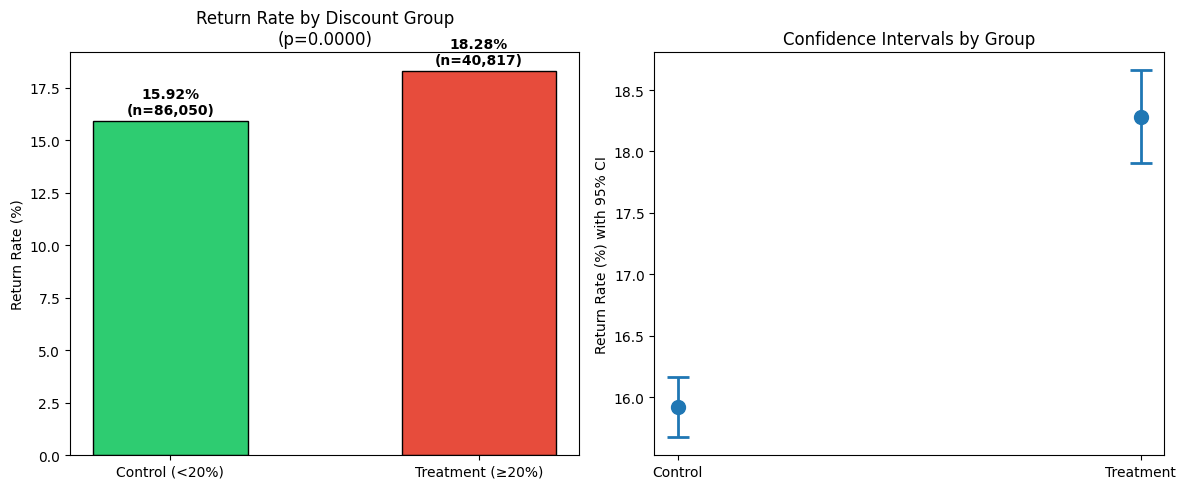

A/B test visualization saved at reports/ab_test_results.png


In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = ['Control (<20%)', 'Treatment (≥20%)']
rates = [control_rate*100, treatment_rate*100]
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(groups, rates, color=colors, width=0.5, edgecolor='black')
axes[0].set_ylabel('Return Rate (%)')
axes[0].set_title(f'Return Rate by Discount Group\n(p={pvalue:.4f})')
for i, (rate, n) in enumerate(zip(rates, [control_n, treatment_n])):
    axes[0].text(i, rate + 0.2, f'{rate:.2f}%\n(n={n:,})', ha='center', va='bottom', fontweight='bold')

axes[1].errorbar(
    ['Control', 'Treatment'],
    [control_rate*100, treatment_rate*100],
    yerr=[
        [(control_rate - ci_control[0])*100, (treatment_rate - ci_treatment[0])*100],
        [(ci_control[1] - control_rate)*100, (ci_treatment[1] - treatment_rate)*100]
    ],
    fmt='o', capsize=8, capthick=2, markersize=10, linewidth=2
)
axes[1].set_ylabel('Return Rate (%) with 95% CI')
axes[1].set_title('Confidence Intervals by Group')

plt.tight_layout()
plt.show()
plt.savefig("reports/ab_test_results.png", dpi=150, bbox_inches='tight')
plt.close()
print("A/B test visualization saved at reports/ab_test_results.png")